[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digdgeo/Ndvi2Gif/blob/master/workshops/ecoinformatica/notebooks/01_rois_y_estadisticos.ipynb)

# ROIs y estadísticos: Doñana en media hora

**Taller Ndvi2Gif — Jornadas de Ecoinformática, Sevilla, 2 de octubre de 2026**

Dos cosas hay que aprender para usar la librería, y las dos caben en este notebook:

1. **cómo le dices dónde mirar** — cinco maneras de dar un ROI, ninguna de ellas obliga a
   tener un shapefile a mano;
2. **qué estadístico le pides** — porque el mapa cambia más con el estadístico que con el
   índice, y eso casi nunca se cuenta.

Y al final, la gracia: cuatro décadas de inundación de la marisma con MNDWI y Landsat, una
década al lado de la otra en el mismo mapa.

## 0. Preparar el entorno

En **Google Colab**, descomenta la primera línea y ejecuta. La primera vez hay que
autenticarse en Earth Engine, y siempre hay que inicializar con **tu** proyecto: el
`PROJECT` de abajo es lo único que tienes que escribir tuyo.

In [1]:
# !pip install -q ndvi2gif

import json

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

from ndvi2gif import NdviSeasonality

# ee.Authenticate()        # solo la primera vez
PROJECT = 'tu-proyecto-de-earth-engine'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine listo')

/home/diego/miniconda3/envs/ndvi2gif_clean/lib/python3.9/site-packages/geemap/conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✓ Earth Engine listo


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 1. Las cinco maneras de decirle dónde mirar

`NdviSeasonality` acepta en `roi=` una geometría de Earth Engine, pero también **cadenas de
texto** que resuelve ella sola:

| lo que escribes | qué es |
|---|---|
| `'wrs:202,34'` | la escena Landsat (WRS-2) que cubre Doñana |
| `'s2:29SQB'` | el tile MGRS de Sentinel-2 |
| `'zona.shp'` / `'zona.geojson'` | un fichero en disco |
| `'deimsid:https://deims.org/bcbc...'` | un sitio de **DEIMS.org**, la red eLTER |
| *nada* | lo que dibujes en el mapa |

La geometría resuelta se queda en `.roi`, así que las pedimos y las echamos al mapa.

> **Un desajuste de librerías, en directo.** El GeoJSON de abajo no lo cargamos con
> `roi='marisma.geojson'` sino convirtiéndolo nosotros con `ee.FeatureCollection`. ¿Por qué?
> Porque `geemap` movió `geojson_to_ee` fuera de su espacio de nombres en la versión 0.36, y
> hoy esa ruta falla en cualquier instalación nueva —Colab incluido— con
> `AttributeError: module 'geemap' has no attribute 'geojson_to_ee'`. Ya está corregido en
> el repositorio de Ndvi2Gif y saldrá en la próxima versión. Es el precio de montar sobre
> otras librerías: se mueven debajo de ti, y conviene saber bajarse del tren un momento y
> hacer la conversión a mano.

In [2]:
DONANA = 'deimsid:https://deims.org/bcbc866c-3f4f-47a8-bbbc-0a93df6de7b2'

# un GeoJSON no tiene por qué venir de ningún sitio: se escribe. Y se convierte en
# geometría de Earth Engine en una línea, sin pasar por nadie más
marisma = {'type': 'FeatureCollection', 'features': [
    {'type': 'Feature', 'properties': {'nombre': 'marisma'},
     'geometry': {'type': 'Polygon', 'coordinates': [[
         [-6.47, 36.90], [-6.14, 36.90], [-6.14, 37.14], [-6.47, 37.14], [-6.47, 36.90]]]}}]}


def resolver(roi):
    """La geometría a la que Ndvi2Gif traduce cada forma de ROI."""
    return NdviSeasonality(roi=roi, start_year=2024, end_year=2024).roi


rois = {'wrs:202,34 (escena Landsat)': resolver('wrs:202,34'),
        's2:29SQB (tile Sentinel-2)': resolver('s2:29SQB'),
        'marisma (GeoJSON)': ee.FeatureCollection(marisma).geometry(),
        'LTSER Doñana (DEIMS)': resolver(DONANA)}

for nombre, geometria in rois.items():
    print('%-30s %8.0f km²' % (nombre, geometria.area(1000).getInfo() / 1e6))

There we go again...
Loading Landsat WRS-2 geometry from GitHub...


Found Landsat tile for Path 202, Row 34
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Loading Sentinel-2 MGRS tile from GitHub...


Found Sentinel-2 tile for 29SQB
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Con Deims hemos topado, amigo Sancho...


Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


wrs:202,34 (escena Landsat)       31618 km²


s2:29SQB (tile Sentinel-2)        12041 km²


marisma (GeoJSON)                   782 km²


LTSER Doñana (DEIMS)               2731 km²


In [3]:
COLORES = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

Mapa = geemap.Map(center=[37.0, -6.35], zoom=8)
Mapa.add_basemap('SATELLITE')
for (nombre, geometria), color in zip(rois.items(), COLORES):
    Mapa.addLayer(geometria, {'color': color}, nombre)
Mapa

Map(center=[37.0, -6.35], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

La escena de Landsat y el tile de Sentinel-2 son cómodos para una prueba rápida, pero son
**cuadrículas del satélite**, no el sitio de estudio: traen de todo, incluido mar. El
polígono de DEIMS es la plataforma LTSER de Doñana tal y como está publicada, y es el que
usaremos en la última sección.

### La quinta: dibujarlo a mano

Dibuja un rectángulo o un polígono con la barra de herramientas del mapa de arriba y la
celda siguiente lo recoge. `Map.user_roi` te da la geometría y `Map.draw_last_feature` el
*feature* completo; las dos valen en `roi=`. Si no dibujas nada seguimos con la marisma, así
que el notebook no se rompe si lo ejecutas de un tirón.

In [4]:
roi = Mapa.user_roi if Mapa.user_roi is not None else rois['marisma (GeoJSON)']
print('ROI dibujado por ti' if Mapa.user_roi is not None else 'ROI por defecto: la marisma')
print('%.0f km²' % (ee.Geometry(roi).area(1000).getInfo() / 1e6))

ROI por defecto: la marisma


782 km²


## 2. El estadístico manda

El compuesto estacional clásico de Ndvi2Gif: un año, cuatro periodos y el **máximo** de NDVI
dentro de cada uno. Las tres primeras estaciones van a rojo, verde y azul, así que lo que
ves son diferencias de fenología — no un color bonito, sino *cuándo* verdea cada cosa.

In [5]:
MARISMA = rois['marisma (GeoJSON)']

estacional = NdviSeasonality(roi=MARISMA, sat='S2', index='ndvi', periods=4,
                             start_year=2024, end_year=2024, key='max',
                             cloud_filter=True, max_cloud_cover=20)
compuesto = estacional.get_year_composite().first()
print(compuesto.bandNames().getInfo())

RGB = {'bands': ['winter', 'spring', 'summer'], 'min': 0.05, 'max': 0.85}

MapaNDVI = geemap.Map()
MapaNDVI.centerObject(MARISMA, 11)
MapaNDVI.add_basemap('SATELLITE')
MapaNDVI.addLayer(compuesto, RGB, 'NDVI 2024 — invierno, primavera, verano')
MapaNDVI

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


['winter', 'spring', 'summer', 'autumn']


Map(center=[37.02005103628916, -6.305000000000179], controls=(WidgetControl(options=['position', 'transparent_…

Y ahora lo que de verdad cambia el mapa. El mismo índice, el mismo año, el mismo ROI: solo
cambia **el reductor** con el que se resume la pila de imágenes de cada periodo.

- `key='max'` — lo más verde que llegó a estar. Es el del GIF clásico, y el que más se
  contamina con un píxel raro: un borde de nube deja un máximo altísimo.
- `key='median'` — el estado típico. El honesto para comparar entre años.
- `key='mean'` — la media, sensible a los extremos pero menos que el máximo.
- `key='percentile'` con 90 o 95 — casi el máximo, pero sin el píxel raro.

Enciende y apaga las capas: es el mismo sitio cinco veces.

In [6]:
ESTADISTICOS = [('max', None), ('median', None), ('mean', None),
                ('percentile', 90), ('percentile', 95)]

MapaKeys = geemap.Map()
MapaKeys.centerObject(MARISMA, 11)
MapaKeys.add_basemap('SATELLITE')

veranos = {}
for key, pct in ESTADISTICOS:
    extra = {'percentile': pct} if pct is not None else {}
    compuesto_key = NdviSeasonality(roi=MARISMA, sat='S2', index='ndvi', periods=4,
                                    start_year=2024, end_year=2024, key=key,
                                    cloud_filter=True, max_cloud_cover=20,
                                    **extra).get_year_composite().first()
    etiqueta = key if pct is None else 'percentil %d' % pct
    MapaKeys.addLayer(compuesto_key, RGB, 'NDVI 2024 — %s' % etiqueta, shown=key == 'max')
    veranos[etiqueta] = compuesto_key.select('summer')
MapaKeys

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


...

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2024: 4/4 periods with data using ndvi index


Map(center=[37.02005103628916, -6.305000000000179], controls=(WidgetControl(options=['position', 'transparent_…

In [7]:
# y el número, que a veces ayuda: el NDVI medio del verano con cada reductor
medias = ee.Dictionary({
    etiqueta: imagen.reduceRegion(ee.Reducer.mean(), MARISMA, 100,
                                  maxPixels=1e9).values().get(0)
    for etiqueta, imagen in veranos.items()}).getInfo()

pd.Series(medias).round(3).to_frame('NDVI medio del verano de 2024 en la marisma')

,NDVI medio del verano de 2024 en la marisma
max,0.298
mean,0.221
median,0.226
percentil 90,0.284
percentil 95,0.293


### Y el GIF, que es de donde viene el nombre

`get_gif()` monta la animación: un fotograma por año, con tres periodos como RGB. Ocho años
de la marisma en una línea. Deja dos ficheros en el directorio de trabajo, el GIF y una
versión con el año rotulado.

Para llevarse los compuestos a QGIS, el equivalente es `get_export()` (un GeoTIFF por
periodo) o `get_export_single()` para una imagen concreta.

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2017: 4/4 periods with data using ndvi index


Year 2018: 4/4 periods with data using ndvi index


Year 2019: 4/4 periods with data using ndvi index


Year 2020: 4/4 periods with data using ndvi index


...

Year 2022: 4/4 periods with data using ndvi index


Year 2023: 4/4 periods with data using ndvi index


Year 2024: 4/4 periods with data using ndvi index
Generating URL...


Please wait ...


The GIF image has been saved to: /tmp/claude-1000/-home-diego-git-Ndvi2Gif/058151fe-0128-43aa-8abd-f2684877e860/scratchpad/donana_ndvi.gif


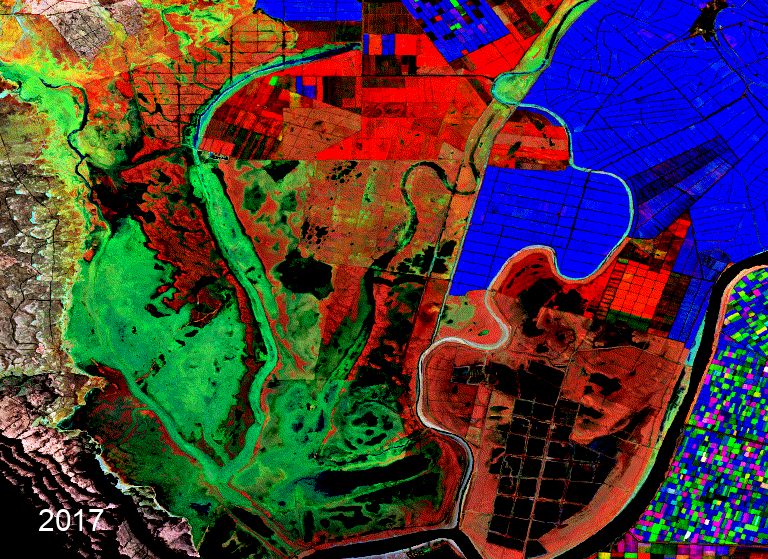

In [8]:
serie = NdviSeasonality(roi=MARISMA, sat='S2', index='ndvi', periods=4,
                        start_year=2017, end_year=2024, key='median',
                        cloud_filter=True, max_cloud_cover=20)
serie.get_gif('donana_ndvi.gif', bands=['winter', 'spring', 'summer'])

from IPython.display import Image
Image('donana_ndvi_texted.gif')

## 3. Cuatro décadas de inundación con MNDWI

MNDWI (verde frente a SWIR) es positivo sobre agua libre, así que:

- el **percentil 95 de MNDWI de un año** es, píxel a píxel, lo más inundado que estuvo ese
  año, sin que una sola imagen con nube decida el resultado;
- resumiendo la década de dos maneras —su **máximo** y su **mediana**— se ve algo que no
  esperábamos. Las dos están en el mapa; enciéndelas y apágalas.

Cuarenta años de Landsat sobre el LTSER de Doñana, dos líneas por década.

In [9]:
LTSER = rois['LTSER Doñana (DEIMS)']
DECADAS = [(1985, 1994), (1995, 2004), (2005, 2014), (2015, 2024)]
ETIQUETAS = ['%d-%d' % (a, b) for a, b in DECADAS]


def p95_anual(anio):
    """El percentil 95 de MNDWI de un año: su inundación máxima robusta."""
    return NdviSeasonality(roi=LTSER, sat='Landsat', index='mndwi', periods=1,
                           start_year=anio, end_year=anio, key='percentile',
                           percentile=95, cloud_filter=True,
                           max_cloud_cover=60).get_year_composite().first()


anuales = {etiqueta: ee.ImageCollection([p95_anual(anio) for anio in range(a, b + 1)])
           for etiqueta, (a, b) in zip(ETIQUETAS, DECADAS)}

maxima = {e: c.max().rename('mndwi') for e, c in anuales.items()}      # el año más húmedo
tipica = {e: c.median().rename('mndwi') for e, c in anuales.items()}   # el año corriente
print('grafos montados; Earth Engine todavía no ha calculado nada')

There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1985: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1986: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1987: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 1988: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


...

Year 2020: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2021: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2022: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2023: 1/1 periods with data using mndwi index
There we go again...
Applying cloud filter to Landsat: max 60% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering


Year 2024: 1/1 periods with data using mndwi index
grafos montados; Earth Engine todavía no ha calculado nada


In [10]:
AGUA = ['f2efe6', 'cfe3ef', '79b7d4', '2f7bb5', '0b3d73']
VIS = {'min': -0.4, 'max': 0.6, 'palette': AGUA}

MapaDecadas = geemap.Map()
MapaDecadas.centerObject(LTSER, 10)
MapaDecadas.add_basemap('SATELLITE')
for etiqueta in ETIQUETAS:
    MapaDecadas.addLayer(maxima[etiqueta], VIS, 'Máximo %s' % etiqueta,
                         shown=etiqueta == ETIQUETAS[0])
for etiqueta in ETIQUETAS:
    MapaDecadas.addLayer(tipica[etiqueta], VIS, 'Mediana %s' % etiqueta, shown=False)
MapaDecadas.add_colorbar(VIS, label='MNDWI  (positivo = agua)', orientation='horizontal')
MapaDecadas

Map(center=[37.144055712604974, -6.438186160520931], controls=(WidgetControl(options=['position', 'transparent…

In [11]:
HECTAREAS = ee.Image.pixelArea().divide(1e4)
LTSER_HA = LTSER.area(1000).getInfo() / 1e4

SENSORES = ['LANDSAT/LT04/C02/T1_L2', 'LANDSAT/LT05/C02/T1_L2',
            'LANDSAT/LE07/C02/T1_L2', 'LANDSAT/LC08/C02/T1_L2',
            'LANDSAT/LC09/C02/T1_L2']
archivo = ee.ImageCollection(SENSORES[0])
for nombre in SENSORES[1:]:
    archivo = archivo.merge(ee.ImageCollection(nombre))
archivo = archivo.filterBounds(LTSER).filter(ee.Filter.lte('CLOUD_COVER', 60))


def hectareas_de_agua(imagen):
    return imagen.gt(0).selfMask().multiply(HECTAREAS).reduceRegion(
        ee.Reducer.sum(), LTSER, 100, maxPixels=1e10, bestEffort=True,
        tileScale=4).values().get(0)


peticion = ee.List([
    ee.Dictionary({'década': etiqueta,
                   'escenas': archivo.filterDate('%d-01-01' % a,
                                                 '%d-01-01' % (b + 1)).size(),
                   'ha (máximo)': hectareas_de_agua(maxima[etiqueta]),
                   'ha (mediana)': hectareas_de_agua(tipica[etiqueta])})
    for etiqueta, (a, b) in zip(ETIQUETAS, DECADAS)])

superficie = pd.DataFrame(peticion.getInfo()).set_index('década').loc[ETIQUETAS]
superficie['% máximo'] = 100 * superficie['ha (máximo)'] / LTSER_HA
superficie['% mediana'] = 100 * superficie['ha (mediana)'] / LTSER_HA
superficie.round(1)

,escenas,ha (mediana),ha (máximo),% máximo,% mediana
década,,,,,
1985-1994,417,67478.3,259661.4,95.1,24.7
1995-2004,594,70591.5,110432.7,40.4,25.8
2005-2014,646,65398.2,102283.7,37.4,23.9
2015-2024,1236,55977.9,81783.6,29.9,20.5


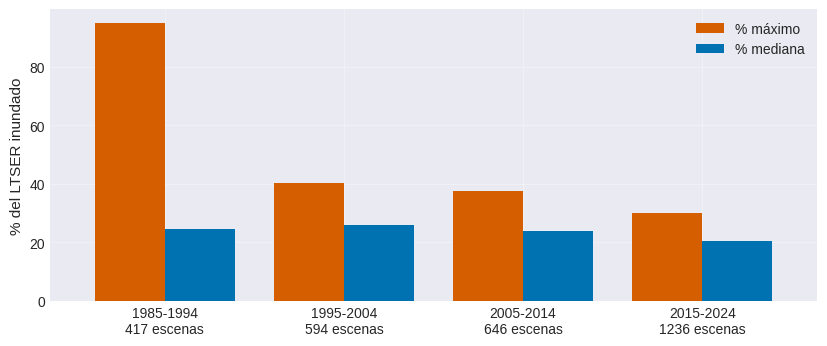

In [12]:
# una gráfica, ahora que los rásters ya están hechos
eje = superficie[['% máximo', '% mediana']].plot.bar(
    figsize=(8.4, 3.6), color=['#D55E00', '#0072B2'], rot=0, width=0.78)
eje.set_ylabel('% del LTSER inundado')
eje.set_xlabel('')
eje.set_xticklabels(['%s\n%d escenas' % (e, superficie.loc[e, 'escenas'])
                     for e in ETIQUETAS])
eje.legend(frameon=False)
eje.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Lo que de verdad dice la tabla

Leída por la columna del máximo, Doñana se ha secado sin remedio: del **95 % del LTSER**
inundado en algún momento de 1985-94 al **30 %** en 2015-24. Es una conclusión redonda, es
la que todo el mundo espera, y es falsa.

Mira la columna de las escenas: **417** imágenes de Landsat en la primera década y **1 236**
en la última, tres veces más. Con 417 escenas en diez años, el percentil 95 de un año es
prácticamente su máximo, y el máximo de diez máximos acaba recogiendo cualquier observación
mala —bruma, sombra, un borde de nube— en cualquier punto del mapa, incluidas las dunas y el
pinar, que no se inundan jamás. Ese 95 % no es marisma: es ruido acumulado durante diez
años.

La **mediana** de los p95 anuales —el año corriente de la década en lugar del extremo—
apenas se mueve: **24,7 / 25,8 / 23,9 / 20,5 %**. Y ahí sí queda una señal, la de la última
década: en torno a un 15 % menos de superficie inundada típica que en las tres anteriores.
Además es conservadora, porque el sesgo del muestreo empuja al alza y la última década es la
que más veces se miró: si con tres veces más imágenes sale menos agua, es que hay menos
agua.

La regla, que sirve para todo lo que hagas con series largas de satélite: **un estadístico
de extremo crece con el número de observaciones, y uno central mucho menos**. Si vas a
comparar décadas, usa el central — o pon el número de escenas al lado de la cifra.

Es el mismo problema que el tutorial de incendios del libro trata a fondo, con cuarenta años
de Landsat sobre toda la península. Y para el hidroperiodo de verdad —cuántos días estuvo
inundado cada píxel, no solo si lo estuvo— la librería tiene una clase entera,
`HydroperiodAnalyzer`, que es el siguiente notebook del taller.

## Para seguir

- El libro: **https://digdgeo.github.io/Ndvi2Gif/** — tutoriales, referencia de los más de
  40 índices y las opciones de ROI con todo detalle.
- `02_hidroperiodo.ipynb` y `03_fenologia.ipynb` en esta misma carpeta.
- Y si algo no funciona: https://github.com/Digdgeo/Ndvi2Gif/issues